# 10. Comparación de resultados

Sección 9.10.4.8 del enunciado. Este capítulo reúne en tablas y gráficos los resultados de los
capítulos 6 a 8: métricas de los seis modelos en los dos entornos, tiempos de cómputo por etapa,
curvas ROC y el resumen de las pruebas de DeLong, McNemar y bootstrap pareado.

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve

import modelado as mo
import utils as u

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 200)
ENT = ("sklearn", "spark")
NOMBRE = {"sklearn": "scikit-learn", "spark": "PySpark"}
res = {e: {m: mo.cargar_resultado(e, m) for m in mo.ORDEN} for e in ENT}
pre = {e: u.cargar_json(u.RESULTADOS / f"{e}_preprocesamiento.json") for e in ENT}
punt = {e: mo.leer_puntuaciones(e) for e in ENT}

## 10.1 Métricas en el conjunto de prueba

Umbral de Youden elegido con entrenamiento; AUC ROC y AUC-PR no dependen del umbral.

In [2]:
filas = []
for m in mo.ORDEN:
    for e in ENT:
        r = res[e][m]
        mt = r["metricas_youden"]
        filas.append({"modelo": m, "entorno": NOMBRE[e], "parámetros": str(r["mejores_parametros"]),
                      "AUC CV": r["auc_cv"], "AUC train": r["auc_train"], "AUC prueba": mt["auc_roc"],
                      "AUC-PR": mt["auc_pr"], "Accuracy": mt["accuracy"], "Precision": mt["precision"],
                      "Recall": mt["recall"], "F1": mt["f1"], "umbral": r["umbral_youden"]})
metr = pd.DataFrame(filas).set_index(["modelo", "entorno"])
metr.to_csv(u.RESULTADOS / "tabla_metricas.csv")
metr.round(4)

parámetros  AUC CV  AUC train  AUC prueba  AUC-PR  Accuracy  Precision  Recall      F1  umbral
modelo             entorno                                                                                                                                 
LogisticRegression scikit-learn             {'C': 0.009272592904426457}  0.7166     0.7168      0.7171  0.3816    0.6478     0.3187  0.6704  0.4320  0.1926
                   PySpark                         {'regParam': 0.0001}  0.7166     0.7168      0.7171  0.3817    0.6441     0.3169  0.6759  0.4315  0.1906
DecisionTree       scikit-learn                       {'max_depth': 10}  0.7024     0.7167      0.7041  0.3615    0.6403     0.3110  0.6589  0.4226  0.2003
                   PySpark                             {'maxDepth': 10}  0.7016     0.7080      0.7014  0.3577    0.6380     0.3085  0.6542  0.4193  0.1999
RandomForest       scikit-learn  {'max_depth': 15, 'n_estimators': 100}  0.7192     0.8066      0.7197  0.3881    0.6856     0.3393  0.6059  0.4350  0.2232
                   PySpark            {'numTrees': 100, 'maxDepth': 15}  0.7180     0.7959      0.7181  0.3859    0.6833     0.3380  0.6101  0.4350  0.2201
GradientBoosting   scikit-learn   {'max_depth': 5, 'n_estimators': 100}  0.7231     0.7281      0.7235  0.3948    0.6529     0.3233  0.6749  0.4372  0.1985
                   PySpark              {'maxIter': 100, 'maxDepth': 5}  0.7221     0.7275      0.7228  0.3930    0.6547     0.3240  0.6704  0.4369  0.1980
LinearSVC          scikit-learn             {'C': 0.009272592904426457}  0.5055     0.5392      0.5391  0.2228    0.5187     0.2181  0.5449  0.3115 -1.0000
                   PySpark                          {'regParam': 1e-06}  0.6499     0.6467      0.6436  0.3253    0.6548     0.3006  0.5487  0.3884 -1.0000
NaiveBayes         scikit-learn                                      {}  0.6526     0.6528      0.6525  0.2953    0.6199     0.2898  0.6220  0.3954  0.2115
                   PySpark                                           {}  0.6525     0.6528      0.6525  0.2953    0.6199     0.2898  0.6220  0.3954  0.2115

Los dos entornos producen modelos casi idénticos en desempeño: en los cinco modelos comparables
la diferencia de AUC de prueba entre entornos es de 0,003 o menos, y el F1 difiere en menos de
0,004. La columna "AUC train" muestra el sobreajuste de los modelos de alta capacidad:
el bosque de profundidad 15 alcanza 0,81 (scikit-learn) y 0,80 (PySpark) en entrenamiento frente
a 0,72 en prueba, y aun así es el segundo mejor en prueba; el gradient boosting, más regularizado
por su tasa de aprendizaje y su poca profundidad, se mantiene en 0,73 frente a 0,72. El de mejor
desempeño discriminativo en ambos entornos es el gradient boosting (AUC 0,7235 en scikit-learn y
0,7228 en PySpark; AUC-PR 0,395 y 0,393), aunque en el umbral de Youden la mayor precisión (0,339
y 0,338) y la mayor exactitud (0,686 y 0,683) corresponden al bosque aleatorio, que marca menos
préstamos como default.

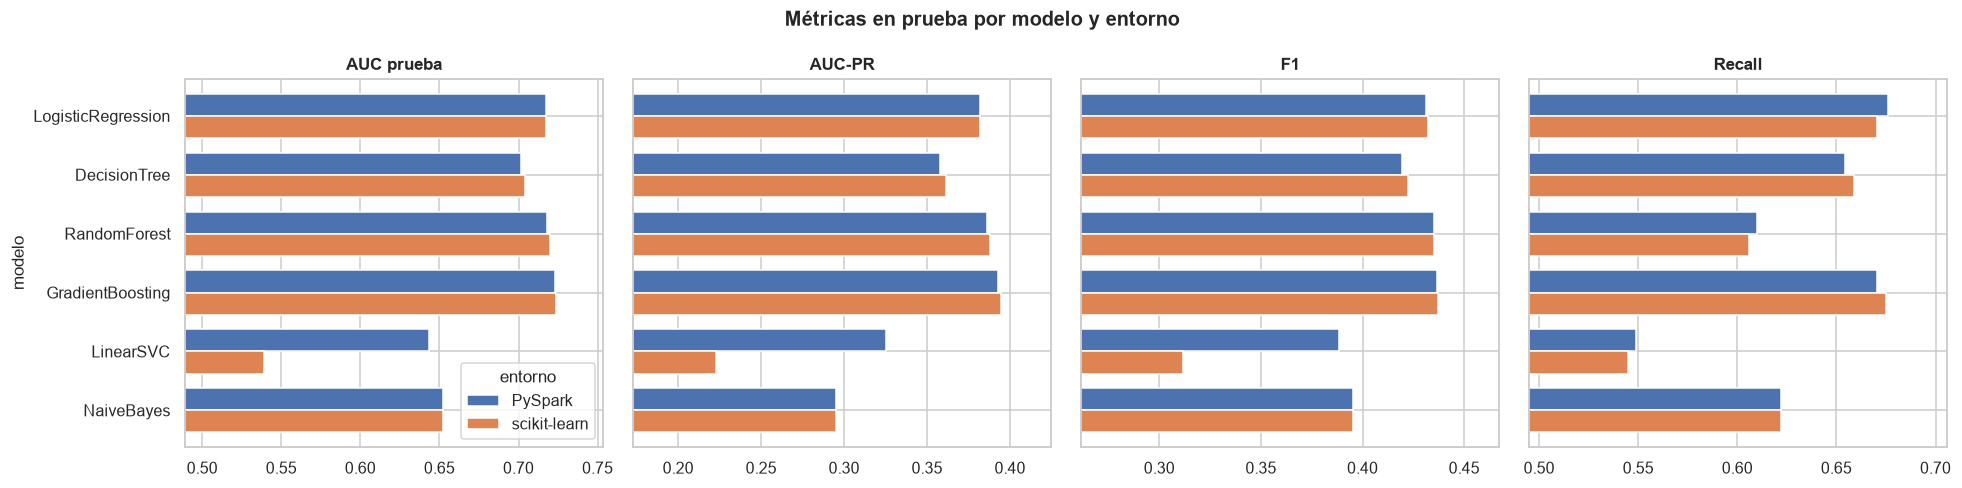

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, k in zip(axes, ["AUC prueba", "AUC-PR", "F1", "Recall"]):
    t = metr[k].unstack("entorno").loc[mo.ORDEN]
    t.plot.barh(ax=ax, color=["#4C72B0", "#DD8452"], width=0.75, legend=(k == "AUC prueba"))
    ax.set_title(k)
    ax.set_xlim(max(0, t.values.min() - 0.05), min(1, t.values.max() + 0.03))
    ax.invert_yaxis()
fig.suptitle("Métricas en prueba por modelo y entorno", fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "10_metricas")
plt.show()

## 10.2 Curvas ROC (una figura por entorno)

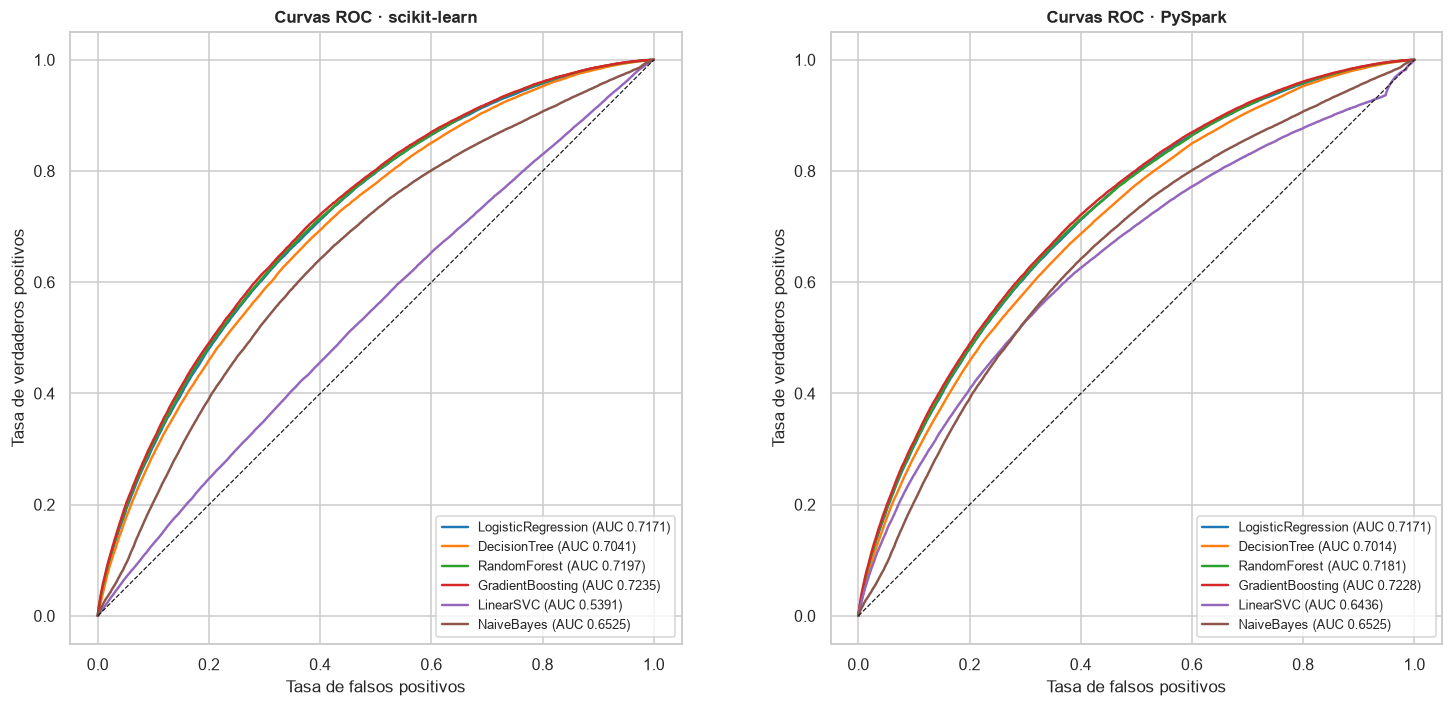

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
colores = dict(zip(mo.ORDEN, sns.color_palette("tab10", 6)))
for ax, e in zip(axes, ENT):
    y = punt[e]["default"].to_numpy()
    for m in mo.ORDEN:
        fpr, tpr, _ = roc_curve(y, punt[e][m])
        ax.plot(fpr, tpr, color=colores[m], lw=1.6,
                label=f"{m} (AUC {res[e][m]['metricas_youden']['auc_roc']:.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(f"Curvas ROC · {NOMBRE[e]}")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.legend(loc="lower right", fontsize=8.5)
    ax.set_aspect("equal")
fig.tight_layout()
u.guardar_fig(fig, "10_roc")
plt.show()

Las curvas ROC de los dos entornos son prácticamente superponibles para los cuatro mejores
modelos, que forman un haz estrecho; Naive Bayes queda por debajo en todo el rango, y el SVM de
scikit-learn sigue la diagonal, mientras que el de PySpark se separa de ella.

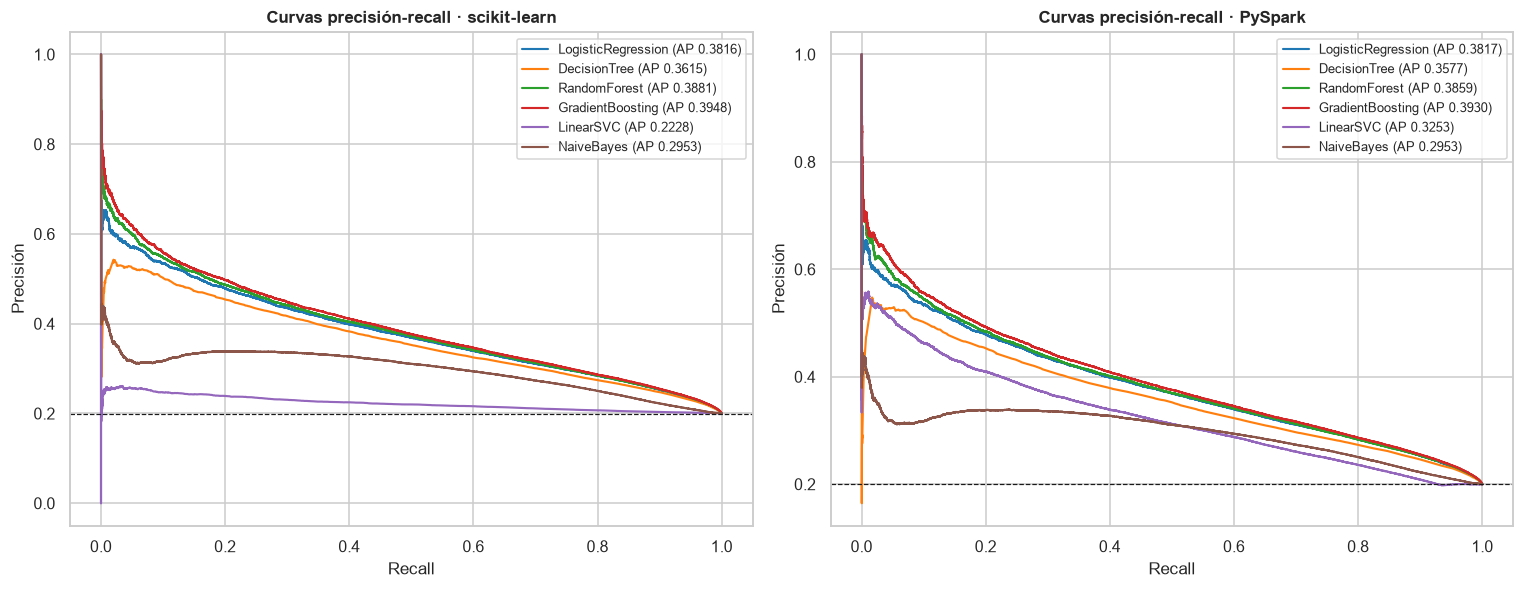

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, e in zip(axes, ENT):
    y = punt[e]["default"].to_numpy()
    for m in mo.ORDEN:
        pr, rc, _ = precision_recall_curve(y, punt[e][m])
        ax.plot(rc, pr, color=colores[m], lw=1.4, label=f"{m} (AP {res[e][m]['metricas_youden']['auc_pr']:.4f})")
    ax.axhline(y.mean(), color="k", ls="--", lw=0.8)
    ax.set_title(f"Curvas precisión-recall · {NOMBRE[e]}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precisión")
    ax.legend(fontsize=8.5)
fig.tight_layout()
u.guardar_fig(fig, "10_pr")
plt.show()

In [6]:
filas = {}
for e in ENT:
    for m in ["GradientBoosting", "RandomForest", "LogisticRegression"]:
        pr, rc, _ = precision_recall_curve(punt[e]["default"], punt[e][m])
        filas[(m, NOMBRE[e])] = pr[np.argmin(np.abs(rc - 0.5))]
pd.Series(filas, name="precisión con recall de 50 %").unstack().round(3)

,PySpark,scikit-learn
GradientBoosting,0.376,0.377
LogisticRegression,0.369,0.369
RandomForest,0.370,0.372


En las curvas precisión-recall, la línea punteada es la precisión de un clasificador aleatorio
(0,20). A un recall de 50 % los tres mejores modelos alcanzan una precisión de 0,37 a 0,38 en
ambos entornos: menos de dos de cada cinco préstamos señalados como riesgosos terminan en
default.

## 10.3 Tiempos de cómputo

* **Preprocesamiento**: en ambos entornos, desde el CSV comprimido hasta la matriz de diseño de
  entrenamiento y prueba: lectura, filtro de préstamos cerrados, construcción de variables, unión
  con la partición común y ajuste/transformación del preprocesamiento (en PySpark, además, la
  materialización de la caché).
* **Entrenamiento con validación**: `GridSearchCV.fit` / `CrossValidator.fit`, incluido el
  reajuste del mejor modelo con todo el entrenamiento.
* **Predicción**: puntuaciones de las 269.612 observaciones de prueba (en Spark, `transform` +
  materialización).
* **Transferencia**: solo PySpark, `toPandas()` de `id`, `default` y la puntuación.

In [7]:
filas = []
for m in mo.ORDEN:
    for e in ENT:
        r = res[e][m]
        filas.append({"modelo": m, "entorno": NOMBRE[e], "ajustes": r["n_ajustes"],
                      "entrenamiento + CV (s)": r["t_entrenamiento_cv_s"], "predicción (s)": r["t_prediccion_s"],
                      "umbral en train (s)": r["t_umbral_s"], "evaluación (s)": r["t_evaluacion_s"],
                      "transferencia (s)": r.get("t_transferencia_s", np.nan)})
tiem = pd.DataFrame(filas).set_index(["modelo", "entorno"])
cociente = (tiem["entrenamiento + CV (s)"].xs("PySpark", level="entorno")
            / tiem["entrenamiento + CV (s)"].xs("scikit-learn", level="entorno"))
tiem.to_csv(u.RESULTADOS / "tabla_tiempos.csv")
print("Preprocesamiento: scikit-learn "
      f"{pre['sklearn']['t_preprocesamiento_s']:.1f} s | PySpark {pre['spark']['t_preprocesamiento_s']:.1f} s")
tot = tiem.groupby("entorno")[["entrenamiento + CV (s)", "predicción (s)", "transferencia (s)"]].sum()
print("\nTotales por entorno (s):")
print(tot.round(1).to_string())
print("\nCociente de tiempo de entrenamiento + CV (PySpark / scikit-learn):")
print(cociente.round(2).to_string())
tiem.round(2)

Preprocesamiento: scikit-learn 17.6 s | PySpark 34.5 s

Totales por entorno (s):
              entrenamiento + CV (s)  predicción (s)  transferencia (s)
entorno                                                                
PySpark                      11494.9            62.9               55.2
scikit-learn                  1966.8             0.9                0.0

Cociente de tiempo de entrenamiento + CV (PySpark / scikit-learn):
modelo
LogisticRegression    13.29
DecisionTree           3.00
RandomForest          10.47
GradientBoosting       7.97
LinearSVC              0.36
NaiveBayes            19.53


ajustes  entrenamiento + CV (s)  predicción (s)  umbral en train (s)  evaluación (s)  transferencia (s)
modelo             entorno                                                                                                              
LogisticRegression scikit-learn       10                    8.55            0.02                 0.09            0.20                NaN
                   PySpark            10                  113.67            0.28                12.22           30.80               0.15
DecisionTree       scikit-learn       10                   20.00            0.04                 0.12            0.17                NaN
                   PySpark            10                   59.95            0.21                 2.66            2.82               0.13
RandomForest       scikit-learn       28                  215.26            0.39                 1.61            0.22                NaN
                   PySpark            28                 2253.80           61.24               202.91          330.11              54.54
GradientBoosting   scikit-learn       13                 1104.89            0.34                 1.38            0.20                NaN
                   PySpark            13                 8805.13            0.63                18.64           35.89               0.09
LinearSVC          scikit-learn       10                  616.15            0.02                 0.08            0.18                NaN
                   PySpark            10                  224.60            0.20                15.38           38.05               0.16
NaiveBayes         scikit-learn        4                    1.93            0.09                 0.32            0.20                NaN
                   PySpark             4                   37.73            0.32                15.93           38.16               0.16

**scikit-learn fue más rápido en cinco de los seis modelos**: el entrenamiento con validación
cruzada de los seis tomó 1.967 s (33 min) en scikit-learn y 11.495 s (3,2 h) en PySpark, 5,8
veces más. En los cinco modelos donde PySpark fue más lento, el cociente va de 3,0 (árbol) a 19,5
(Naive Bayes). La única excepción es el SVM lineal, donde PySpark fue 2,7 veces más rápido (225 s
frente a 616 s): en scikit-learn los ajustes con $C$ = 0,927 tardaron unos 600 s cada uno en
converger cerca de la solución degenerada (capítulos 6 y 11), mientras que Spark limita su
optimizador a 100 iteraciones. No es una ventaja del entorno sino del criterio de parada. El
preprocesamiento también fue más rápido en scikit-learn (17,6 s frente a 34,5 s), y la predicción
de las 269.612 observaciones tardó menos de 0,4 s en scikit-learn frente a 0,2-61 s en PySpark.
Las etapas posteriores (umbral en entrenamiento y métricas distribuidas) suman en PySpark otros
entre 5 y 533 s por modelo, frente a 0,3-1,8 s en scikit-learn. El capítulo 12 explica por
qué.

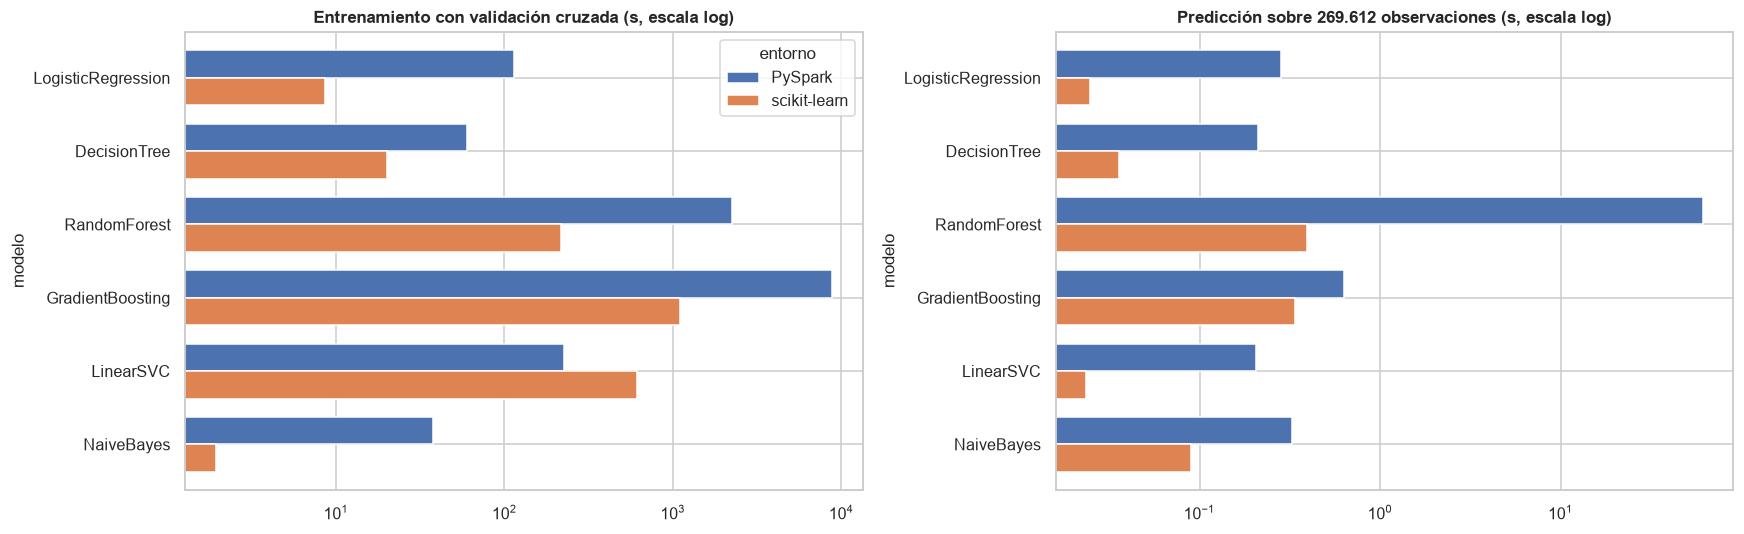

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
t = tiem["entrenamiento + CV (s)"].unstack("entorno").loc[mo.ORDEN]
t.plot.barh(ax=axes[0], color=["#DD8452", "#4C72B0"][::-1], width=0.75, logx=True)
axes[0].set_title("Entrenamiento con validación cruzada (s, escala log)")
axes[0].invert_yaxis()
t = tiem["predicción (s)"].unstack("entorno").loc[mo.ORDEN]
t.plot.barh(ax=axes[1], color=["#DD8452", "#4C72B0"][::-1], width=0.75, logx=True, legend=False)
axes[1].set_title("Predicción sobre 269.612 observaciones (s, escala log)")
axes[1].invert_yaxis()
fig.tight_layout()
u.guardar_fig(fig, "10_tiempos")
plt.show()

## 10.4 Resumen de las pruebas estadísticas

### DeLong entre entornos

In [9]:
de = pd.read_csv(u.RESULTADOS / "delong_entre_entornos.csv")
de["IC 95 % ΔAUC"] = de.apply(lambda r: f"[{r['delta_inf']:+.4f}, {r['delta_sup']:+.4f}]", axis=1)
de["modelo"] = de["modelo_1"].str.split(" ").str[0]
de.set_index("modelo")[["auc1", "auc2", "delta", "IC 95 % ΔAUC", "z", "p_holm", "significativa",
                        "relevante (|Δ| ≥ 0,005)"]].rename(
    columns={"auc1": "AUC scikit-learn", "auc2": "AUC PySpark"}).round(5)

,AUC scikit-learn,AUC PySpark,delta,IC 95 % ΔAUC,z,p_holm,significativa,"relevante (|Δ| ≥ 0,005)"
modelo,,,,,,,,
LogisticRegression,0.71709,0.71710,-0.00001,"[-0.0000, +0.0000]",-0.71977,0.94333,False,False
DecisionTree,0.70415,0.70141,0.00274,"[+0.0017, +0.0037]",5.42500,0.00000,True,False
RandomForest,0.71968,0.71815,0.00153,"[+0.0011, +0.0020]",6.96213,0.00000,True,False
GradientBoosting,0.72349,0.72283,0.00066,"[+0.0002, +0.0011]",2.97442,0.00881,True,False
LinearSVC,0.53908,0.64357,-0.10449,"[-0.1083, -0.1007]",-53.78500,0.00000,True,True
NaiveBayes,0.65251,0.65251,0.00000,"[-0.0000, +0.0000]",0.68152,0.94333,False,False


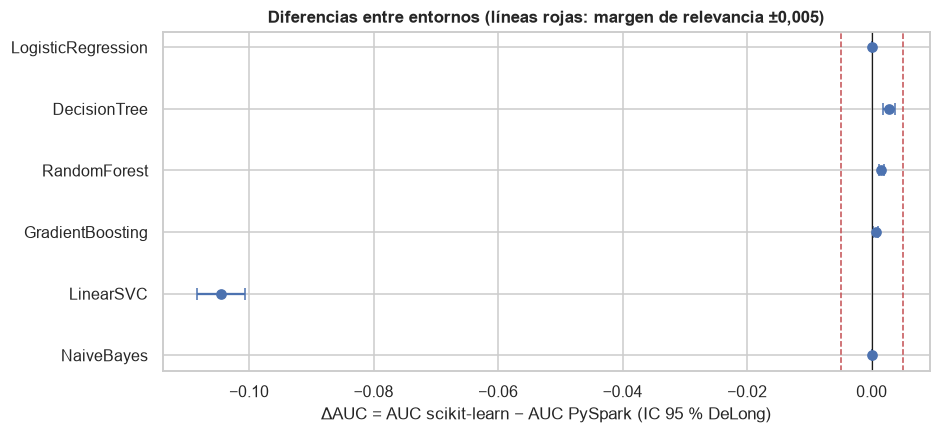

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
d = de.set_index("modelo").loc[mo.ORDEN]
ax.errorbar(d["delta"], range(len(d)), xerr=[d["delta"] - d["delta_inf"], d["delta_sup"] - d["delta"]],
            fmt="o", color="#4C72B0", capsize=4)
for x in (-0.005, 0.005):
    ax.axvline(x, color="#C44E52", ls="--", lw=1)
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(range(len(d)))
ax.set_yticklabels(d.index)
ax.invert_yaxis()
ax.set_xlabel("ΔAUC = AUC scikit-learn − AUC PySpark (IC 95 % DeLong)")
ax.set_title("Diferencias entre entornos (líneas rojas: margen de relevancia ±0,005)")
u.guardar_fig(fig, "10_delong_entornos")
plt.show()

Todos los intervalos, salvo el del SVM, caen dentro de la franja de ±0,005: las diferencias entre
entornos son estadísticamente detectables en tres modelos, pero irrelevantes en la práctica.

### Mapas de calor de DeLong entre modelos

![Mapas de calor de DeLong](figuras/08_delong_heatmaps.png)

### DeLong, McNemar y bootstrap pareado

In [11]:
pd.read_csv(u.RESULTADOS / "resumen_tres_pruebas.csv")

,familia,comparación,ΔAUC,DeLong,McNemar,Bootstrap ΔAUC,Bootstrap ΔAUC-PR,Bootstrap ΔF1
0,entre entornos,LogisticRegression (sklearn) vs LogisticRegres...,-0.0000,no,sí,no,sí (no relevante),sí (no relevante)
1,entre entornos,DecisionTree (sklearn) vs DecisionTree (spark),0.0027,sí (no relevante),sí,sí (no relevante),sí (no relevante),sí (no relevante)
2,entre entornos,RandomForest (sklearn) vs RandomForest (spark),0.0015,sí (no relevante),sí,sí (no relevante),sí (no relevante),no
3,entre entornos,GradientBoosting (sklearn) vs GradientBoosting...,0.0007,sí (no relevante),sí,sí (no relevante),sí (no relevante),no
4,entre entornos,LinearSVC (sklearn) vs LinearSVC (spark),-0.1045,sí (relevante),sí,sí (relevante),sí (relevante),sí (relevante)
5,entre entornos,NaiveBayes (sklearn) vs NaiveBayes (spark),0.0000,no,no,no,no,no
6,mejores modelos,GradientBoosting (sklearn) vs RandomForest (sk...,0.0038,sí (no relevante),sí,sí (no relevante),sí (relevante),sí (no relevante)
7,mejores modelos,GradientBoosting (spark) vs RandomForest (spark),0.0047,sí (no relevante),sí,sí (no relevante),sí (relevante),sí (no relevante)


La tabla resume el capítulo 8. DeLong y el bootstrap coinciden en que el SVM es la única
diferencia relevante entre entornos; McNemar, que no evalúa relevancia, rechaza la igualdad de
errores en cinco de las seis comparaciones (todas salvo Naive Bayes). DeLong y el bootstrap
coinciden también en que el gradient boosting supera al bosque dentro de cada entorno, mientras
que McNemar es significativo en sentido contrario (el bosque comete menos errores en su umbral).
En la regresión logística entre entornos, DeLong y el bootstrap del AUC no detectan diferencia,
pero McNemar y el bootstrap de AUC-PR y F1 sí, aunque irrelevante (ΔAUC-PR = −0,0001; ΔF1 =
0,0006), por la pequeña diferencia de umbrales.